# Species Classification on Camera-Trap Images — v3

Fine-tuned ResNet-18 on **iWildCam 2020 (WILDS v2.0)**, scored on camera locations the model
has never seen.

**Result: 0.446 honest macro F1 on unseen cameras**, up from v2's 0.421, and 0.543 on the
all-class macro against v2's 0.505. Held-out-date performance barely moved (0.666 to 0.674),
so the gain is specifically in generalizing to new sites, which is what the changes were
aimed at. Section 10 has the full reading, including why this is a smaller win than the step
from scratch-training to pretraining, and why the next move is not more tuning.

v2 established two things. Closing the overfitting gap on a from-scratch CNN raised
held-out-date macro F1 from 0.489 to 0.545 and left unseen-camera macro F1 at 0.434,
unchanged — regularization does not touch the location shortcut. Swapping in an
ImageNet-pretrained ResNet-18 did move it, to 0.505, but that run was left overfitting badly
(0.991 train against 0.776 validation by epoch 10) and ran at 128x128, below the resolution
its features were learned at.

This notebook takes the four next steps that came out of that:

| | v2 | v3 |
|---|---|---|
| input resolution | 128x128 | 192x192 (`IMG_SIZE`) |
| fine-tuning | one learning rate for every layer | discriminative rates, stem barely moves |
| regularization | augmentation + label smoothing | adds mixup |
| evaluation | per-class | adds per-camera and contested-camera scores |

It also carries over what v2 proved worth keeping: official WILDS splits, sequence-aware
sampling, best-epoch restore, and `honest_macro_f1`, which excludes the two classes that are
separable by camera site alone.

## 1. Setup

In [1]:
import io
import math
import time
import zipfile
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
SEED = 42


def set_seed(seed=SEED):
    "Reset every random source so two runs start from identical conditions."
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()
plt.rcParams["figure.figsize"] = (11, 4)
print("torch:", torch.__version__, "| device:", DEVICE)
if DEVICE.type == "cuda":
    free, total = torch.cuda.mem_get_info()
    print(f"gpu: {torch.cuda.get_device_name(0)}  {free / 1e9:.1f} GB free of {total / 1e9:.1f} GB")

torch: 2.11.0+cu128 | device: cuda
gpu: Tesla T4  15.5 GB free of 15.6 GB


## 2. Configuration

`IMG_SIZE` is the one knob worth touching. ResNet-18's features were learned at 224, so
larger is better for accuracy and worse for time and memory. The cached splits come to about
4.4 GB at 192 and 6.0 GB at 224; `place_splits` in section 3.1 measures free GPU memory and
decides where they live, so either will run — 224 just leaves less room for activations and
may push the data back to RAM. Drop to 160 if you want the run to finish faster.

**Check your Drive space first.** The cache is keyed by resolution, so a 192px run writes a
new ~4.4 GB file alongside the 64px and 128px caches from v2 and the 12 GB source archive. If
Drive is tight, delete the older caches, or point `CACHE_DIR` at `/content/iwildcam_cache` —
that costs a re-decode (about five minutes) every time the runtime restarts.

In [2]:
from google.colab import drive
drive.mount("/content/drive")

ZIP_PATH = Path("/content/drive/MyDrive/IWildCam v2.0 2020 WILDS Dataset.zip")

IMG_SIZE = 192       # 224 is ResNet's native size; 160 trades accuracy for speed
N_CLASSES = 10
CAP_TRAIN = 3000
CAP_EVAL = 600

EPOCHS = 12
BATCH_SIZE = 64
BASE_LR = 3e-4       # applies to the head; earlier stages get a fraction of it
MIXUP_ALPHA = 0.2

CACHE_DIR = Path("/content/drive/MyDrive/iwildcam_cache")
CACHE_DIR.mkdir(parents=True, exist_ok=True)

Mounted at /content/drive


## 3. Data

Unchanged from v2: the same reader, the same ten classes, the same sequence-aware sampling,
and the same official splits. Repeated here so this notebook stands on its own.

In [3]:
ROOT = "iwildcam_v2.0"


class IWildCamSource:
    "Reads metadata and image bytes from the WILDS ZIP or from an extracted folder."

    def __init__(self, path):
        path = Path(path)
        self.is_zip = path.suffix.lower() == ".zip"
        if self.is_zip:
            self.zf = zipfile.ZipFile(path)
            self.offsets = {i.filename: i.header_offset for i in self.zf.infolist()}
        else:
            self.dir = path if path.name == ROOT else path / ROOT

    def read(self, rel):
        if self.is_zip:
            return self.zf.read(f"{ROOT}/{rel}")
        return (self.dir / rel).read_bytes()

    def read_order(self, rel):
        "A sort key that makes a batch of reads as sequential as possible."
        return self.offsets.get(f"{ROOT}/{rel}", 0) if self.is_zip else 0


source = IWildCamSource(ZIP_PATH)
metadata = pd.read_csv(io.BytesIO(source.read("metadata.csv")), index_col=0)
categories = pd.read_csv(io.BytesIO(source.read("categories.csv")))

COMMON = {
    "empty": "empty (false trigger)",
    "meleagris ocellata": "ocellated turkey",
    "crax rubra": "great curassow",
    "tayassu pecari": "white-lipped peccary",
    "cephalophus nigrifrons": "black-fronted duiker",
    "dasyprocta punctata": "agouti",
    "leopardus pardalis": "ocelot",
    "mazama temama": "red brocket deer",
    "puma concolor": "puma",
    "urocyon cinereoargenteus": "gray fox",
}

scientific = dict(zip(categories.y, categories.name))
counts = metadata[metadata.split == "train"].y.value_counts()
top_labels = counts.head(N_CLASSES).index.tolist()
CLASS_NAMES = [COMMON.get(scientific[y], scientific[y]) for y in top_labels]
label_to_index = {y: i for i, y in enumerate(top_labels)}

print(f"{'idx':>3} {'class':<24} {'train imgs':>10}")
for i, y in enumerate(top_labels):
    print(f"{i:>3} {CLASS_NAMES[i]:<24} {counts[y]:>10,}")

idx class                    train imgs
  0 empty (false trigger)        48,021
  1 ocellated turkey             10,267
  2 great curassow                7,534
  3 white-lipped peccary          4,078
  4 black-fronted duiker          4,023
  5 agouti                        3,986
  6 ocelot                        3,584
  7 red brocket deer              3,177
  8 puma                          3,091
  9 gray fox                      2,740


In [4]:
def sample_split(split, cap, seed=SEED):
    "Take up to `cap` images per class from one official split, spread across sequences."
    rows = metadata[(metadata.split == split) & (metadata.y.isin(top_labels))]
    rng = np.random.default_rng(seed)
    kept = []

    for y in top_labels:
        cls = rows[rows.y == y]
        groups = list(cls.groupby("seq_id").indices.values())
        rng.shuffle(groups)

        order, depth = [], 0
        while len(order) < len(cls):
            taken = [cls.index[g[depth]] for g in groups if depth < len(g)]
            if not taken:
                break
            order.extend(taken)
            depth += 1

        kept.extend(order[:cap])

    return metadata.loc[kept]


SPLITS = {
    "train":   sample_split("train", CAP_TRAIN),
    "id_val":  sample_split("id_val", CAP_EVAL),
    "id_test": sample_split("id_test", CAP_EVAL),
    "ood_val": sample_split("val", CAP_EVAL),
}

train_locations = set(SPLITS["train"].location_remapped)
print(f"{'split':>8} {'images':>8} {'sequences':>10} {'cameras':>9} {'unseen cameras':>15}")
for name, frame in SPLITS.items():
    locs = set(frame.location_remapped)
    print(f"{name:>8} {len(frame):>8,} {frame.seq_id.nunique():>10,} {len(locs):>9} "
          f"{len(locs - train_locations):>15}")

   split   images  sequences   cameras  unseen cameras
   train   29,740      8,773       208               0
  id_val    2,377        872       107               4
 id_test    3,420        982       137               2
 ood_val    4,361      1,444        29              29


### 3.1 Decoding and placement

The cache is keyed by resolution and lives on Drive, so a given `IMG_SIZE` is decoded once
and every later run loads it in seconds.

`place_splits` then decides where the tensors live. Keeping them on the GPU removes a
host-to-device copy per batch, which is worth real time, but only if they fit next to the
activations — so it measures free memory and falls back to RAM rather than dying partway
through training.

In [5]:
def decode_split(frame, size):
    "Decode one split's images into a (N, 3, size, size) uint8 tensor."
    names = frame.filename.tolist()
    order = sorted(range(len(names)), key=lambda i: source.read_order(f"train/{names[i]}"))
    out = np.empty((len(names), size, size, 3), dtype=np.uint8)

    for done, i in enumerate(order, 1):
        img = Image.open(io.BytesIO(source.read(f"train/{names[i]}")))
        img.draft("RGB", (size, size))
        out[i] = np.asarray(img.convert("RGB").resize((size, size), Image.BILINEAR))
        if done % 10000 == 0:
            print(f"    {done:,}/{len(names):,}")

    x = torch.from_numpy(out).permute(0, 3, 1, 2).contiguous()
    y = torch.tensor([label_to_index[v] for v in frame.y], dtype=torch.long)
    return x, y


def build_cache(size):
    "Decode every split at `size`, caching to Drive so a second run is instant."
    cache = CACHE_DIR / f"iwildcam_{size}px.npz"
    if cache.exists():
        blob = np.load(cache)
        print("loaded cache:", cache)
        return {name: (torch.from_numpy(blob[f"{name}_x"]), torch.from_numpy(blob[f"{name}_y"]))
                for name in SPLITS}

    start = time.perf_counter()
    data = {}
    for name, frame in SPLITS.items():
        print(f"  decoding {name} ({len(frame):,} images)")
        data[name] = decode_split(frame, size)

    np.savez(cache, **{f"{n}_{k}": v.numpy()
                       for n, (x, y) in data.items() for k, v in (("x", x), ("y", y))})
    total = sum(len(y) for _, y in data.values())
    elapsed = time.perf_counter() - start
    print(f"decoded {total:,} images in {elapsed:.0f}s "
          f"({total / elapsed:.0f} img/s), cached to {cache}")
    return data


def place_splits(splits, headroom=0.45):
    "Move the cached tensors to the GPU only if they leave room for activations."
    total = sum(x.nbytes + y.nbytes for x, y in splits.values())
    if DEVICE.type != "cuda":
        print(f"data stays in RAM ({total / 1e9:.2f} GB), no GPU")
        return splits

    free, _ = torch.cuda.mem_get_info()
    if total < free * headroom:
        print(f"data on GPU ({total / 1e9:.2f} GB of {free / 1e9:.1f} GB free)")
        return {k: (x.to(DEVICE), y.to(DEVICE)) for k, (x, y) in splits.items()}

    print(f"data stays in RAM ({total / 1e9:.2f} GB vs {free / 1e9:.1f} GB free); "
          f"batches will be copied across per step")
    return splits


data = place_splits(build_cache(IMG_SIZE))
X_train, y_train = data["train"]
X_val, y_val = data["id_val"]

for name, (x, y) in data.items():
    print(f"{name:>8}: {str(tuple(x.shape)):>24}  {x.nbytes / 1e9:>5.2f} GB  on {x.device}")

loaded cache: /content/drive/MyDrive/iwildcam_cache/iwildcam_192px.npz
data on GPU (4.41 GB of 15.5 GB free)
   train:     (29740, 3, 192, 192)   3.29 GB  on cuda:0
  id_val:      (2377, 3, 192, 192)   0.26 GB  on cuda:0
 id_test:      (3420, 3, 192, 192)   0.38 GB  on cuda:0
 ood_val:      (4361, 3, 192, 192)   0.48 GB  on cuda:0


### 3.2 Normalization and helpers

Pretrained weights expect ImageNet's channel statistics, not this dataset's, so `to_float`
uses those. `iterate_batches` yields device tensors whichever side the cache ended up on.

In [6]:
NORM = {
    "mean": torch.tensor([0.485, 0.456, 0.406], device=DEVICE).view(1, 3, 1, 1),
    "std": torch.tensor([0.229, 0.224, 0.225], device=DEVICE).view(1, 3, 1, 1),
}


def to_float(batch_uint8, norm=None):
    "uint8 pixels (0-255) to normalized float, done per batch to keep memory low."
    norm = NORM if norm is None else norm
    return (batch_uint8.float() / 255 - norm["mean"]) / norm["std"]


def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


def iterate_batches(X, y, batch_size, shuffle):
    "Yield minibatches on DEVICE, copying from RAM only when the cache is not already there."
    n = X.shape[0]
    order = torch.randperm(n, device=X.device) if shuffle else torch.arange(n, device=X.device)
    for start in range(0, n, batch_size):
        idx = order[start:start + batch_size]
        xb, yb = X[idx], y[idx]
        if xb.device != DEVICE:
            xb = xb.to(DEVICE, non_blocking=True)
            yb = yb.to(DEVICE, non_blocking=True)
        yield xb, yb


def augment_batch(xb, scale=(0.65, 1.0), max_rotation=12.0, jitter=0.2):
    """Per-image flip, zoom-crop, small rotation, and brightness/contrast jitter.

    Carried over from v2 unchanged. The geometry is one affine sampling grid for the whole
    batch, so it costs about what a single flip would.
    """
    B = xb.shape[0]
    dev = xb.device
    x = xb.float() / 255.0

    area = torch.empty(B, device=dev).uniform_(*scale)
    s = area.sqrt()
    ang = torch.empty(B, device=dev).uniform_(-max_rotation, max_rotation) * (math.pi / 180)
    flip = torch.where(torch.rand(B, device=dev) < 0.5, -1.0, 1.0)

    cos, sin = torch.cos(ang) * s, torch.sin(ang) * s
    room = (1.0 - s).clamp(min=0.0)
    tx = (torch.rand(B, device=dev) * 2 - 1) * room
    ty = (torch.rand(B, device=dev) * 2 - 1) * room

    theta = torch.zeros(B, 2, 3, device=dev)
    theta[:, 0, 0] = cos * flip
    theta[:, 0, 1] = -sin
    theta[:, 0, 2] = tx
    theta[:, 1, 0] = sin * flip
    theta[:, 1, 1] = cos
    theta[:, 1, 2] = ty

    grid = F.affine_grid(theta, x.shape, align_corners=False)
    x = F.grid_sample(x, grid, mode="bilinear", padding_mode="reflection",
                      align_corners=False)

    bright = 1.0 + (torch.rand(B, 1, 1, 1, device=dev) * 2 - 1) * jitter
    contrast = 1.0 + (torch.rand(B, 1, 1, 1, device=dev) * 2 - 1) * jitter
    mean = x.mean(dim=(1, 2, 3), keepdim=True)
    x = ((x - mean) * contrast + mean) * bright

    return (x.clamp(0, 1) * 255).to(torch.uint8)


@torch.no_grad()
def evaluate(model, X, y, batch_size=256, norm=None):
    model.eval()
    total_loss, correct = 0.0, 0
    for xb, yb in iterate_batches(X, y, batch_size, shuffle=False):
        logits = model(to_float(xb, norm))
        total_loss += F.cross_entropy(logits, yb, reduction="sum").item()
        correct += (logits.argmax(1) == yb).sum().item()
    return total_loss / len(y), correct / len(y)


@torch.no_grad()
def predict(model, X, batch_size=256, norm=None):
    "Predicted class index for every row of X."
    model.eval()
    out = []
    dummy = torch.zeros(len(X), dtype=torch.long, device=X.device)
    for xb, _ in iterate_batches(X, dummy, batch_size, shuffle=False):
        out.append(model(to_float(xb, norm)).argmax(1))
    return torch.cat(out)

## 4. Model

### 4.1 Discriminative learning rates

Fine-tuning every layer at one rate is what left v2 overfitting by epoch 10. A pretrained
stem already encodes edges and colour blobs that transfer to camera-trap frames unchanged,
so there is nothing to gain from moving it much and a lot of pretraining to lose. The later
blocks encode ImageNet-specific object parts and are what genuinely needs to adapt.

`param_groups` gives each stage a learning rate of `BASE_LR * 0.5 ** (distance from the
head)`, so the classifier trains at full rate and the stem at about 1/32 of it.

In [7]:
from torchvision.models import resnet18, ResNet18_Weights


def build_resnet18(n_classes=N_CLASSES):
    "ImageNet-pretrained ResNet-18 with a fresh classification head."
    model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, n_classes)
    return model


def param_groups(model, lr, decay=0.5):
    "One parameter group per stage, each trained slower than the one after it."
    stages = [
        nn.ModuleList([model.conv1, model.bn1]),   # stem: generic edges, barely moves
        model.layer1,
        model.layer2,
        model.layer3,
        model.layer4,                              # ImageNet-specific, needs to adapt
        model.fc,                                  # brand new, trains at full rate
    ]
    groups = [{"params": list(stage.parameters()), "lr": lr * decay ** (len(stages) - 1 - i)}
              for i, stage in enumerate(stages)]

    covered = sum(p.numel() for g in groups for p in g["params"])
    assert covered == sum(p.numel() for p in model.parameters()), "a stage was missed"
    return groups


probe = build_resnet18()
print(f"{'stage':>8} {'params':>12} {'lr':>10}")
for name, grp in zip(["stem", "layer1", "layer2", "layer3", "layer4", "fc"],
                   param_groups(probe, BASE_LR)):
    print(f"{name:>8} {sum(p.numel() for p in grp['params']):>12,} {grp['lr']:>10.2e}")
print(f"{'total':>8} {count_params(probe):>12,}")
del probe

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 251MB/s]


   stage       params         lr
    stem        9,536   9.37e-06
  layer1      147,968   1.87e-05
  layer2      525,568   3.75e-05
  layer3    2,099,712   7.50e-05
  layer4    8,393,728   1.50e-04
      fc        5,130   3.00e-04
   total   11,181,642


### 4.2 Mixup

Mixup trains on blended pairs of images with correspondingly blended labels. It is a good
fit for this failure mode specifically: blending two frames from *different* cameras
destroys any single coherent background, so memorizing one is no longer a way to reduce the
loss. `lam` is kept above 0.5 so the first label always stays the dominant one, which keeps
the reported training accuracy meaningful.

In [8]:
def mixup(x, y, alpha=MIXUP_ALPHA):
    "Blend the batch with a shuffled copy of itself; return both labels and the weight."
    if alpha <= 0:
        return x, y, y, 1.0
    lam = float(np.random.beta(alpha, alpha))
    lam = max(lam, 1.0 - lam)                       # keep y_a dominant
    perm = torch.randperm(x.size(0), device=x.device)
    return lam * x + (1.0 - lam) * x[perm], y, y[perm], lam

### 4.3 Training loop

Same shape as v2's — AdamW, cosine schedule, best-validation weights restored at the end —
with mixup folded into the loss and the optimizer built from the parameter groups above.

In [9]:
def finetune(model, epochs=EPOCHS, lr=BASE_LR, batch_size=BATCH_SIZE, weight_decay=1e-4,
             mixup_alpha=MIXUP_ALPHA, log_every=1, Xtr=None, ytr=None, Xva=None, yva=None,
             norm=None, restore_best=True):
    "Fine-tune with discriminative rates and mixup, keeping the best-validation weights."
    Xtr = X_train if Xtr is None else Xtr
    ytr = y_train if ytr is None else ytr
    Xva = X_val if Xva is None else Xva
    yva = y_val if yva is None else yva

    model = model.to(DEVICE)
    opt = torch.optim.AdamW(param_groups(model, lr), weight_decay=weight_decay)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    hist = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}
    best_acc, best_state, best_epoch = -1.0, None, -1
    start = time.perf_counter()

    for epoch in range(epochs):
        model.train()
        run_loss, run_correct, n = 0.0, 0, 0

        for xb, yb in iterate_batches(Xtr, ytr, batch_size, shuffle=True):
            xf = to_float(augment_batch(xb), norm)
            xf, ya, yb2, lam = mixup(xf, yb, mixup_alpha)

            logits = model(xf)
            loss = (lam * F.cross_entropy(logits, ya, label_smoothing=0.05)
                    + (1 - lam) * F.cross_entropy(logits, yb2, label_smoothing=0.05))

            opt.zero_grad()
            loss.backward()
            opt.step()

            run_loss += loss.item() * len(yb)
            run_correct += (logits.argmax(1) == ya).sum().item()   # vs the dominant label
            n += len(yb)

        sched.step()
        val_loss, val_acc = evaluate(model, Xva, yva, norm=norm)
        hist["train_loss"].append(run_loss / n)
        hist["train_acc"].append(run_correct / n)
        hist["val_loss"].append(val_loss)
        hist["val_acc"].append(val_acc)

        if val_acc > best_acc:
            best_acc, best_epoch = val_acc, epoch + 1
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

        if log_every and (epoch + 1) % log_every == 0:
            print(f"  epoch {epoch + 1:3d}  train {run_correct / n:.3f}  val {val_acc:.3f}  "
                  f"({time.perf_counter() - start:.0f}s)")

    if restore_best and best_state is not None:
        model.load_state_dict(best_state)
        print(f"  restored epoch {best_epoch} (val {best_acc:.3f})")

    hist["seconds"] = time.perf_counter() - start
    hist["best_epoch"], hist["best_acc"] = best_epoch, best_acc
    return model, hist

## 5. Training

In [10]:
set_seed()
model, hist = finetune(build_resnet18())

  epoch   1  train 0.741  val 0.794  (72s)
  epoch   2  train 0.849  val 0.782  (152s)
  epoch   3  train 0.882  val 0.796  (232s)
  epoch   4  train 0.893  val 0.817  (312s)
  epoch   5  train 0.905  val 0.815  (392s)
  epoch   6  train 0.928  val 0.791  (473s)
  epoch   7  train 0.930  val 0.814  (552s)
  epoch   8  train 0.941  val 0.803  (633s)
  epoch   9  train 0.943  val 0.803  (713s)
  epoch  10  train 0.939  val 0.811  (793s)
  epoch  11  train 0.930  val 0.806  (873s)
  epoch  12  train 0.951  val 0.806  (953s)
  restored epoch 4 (val 0.817)


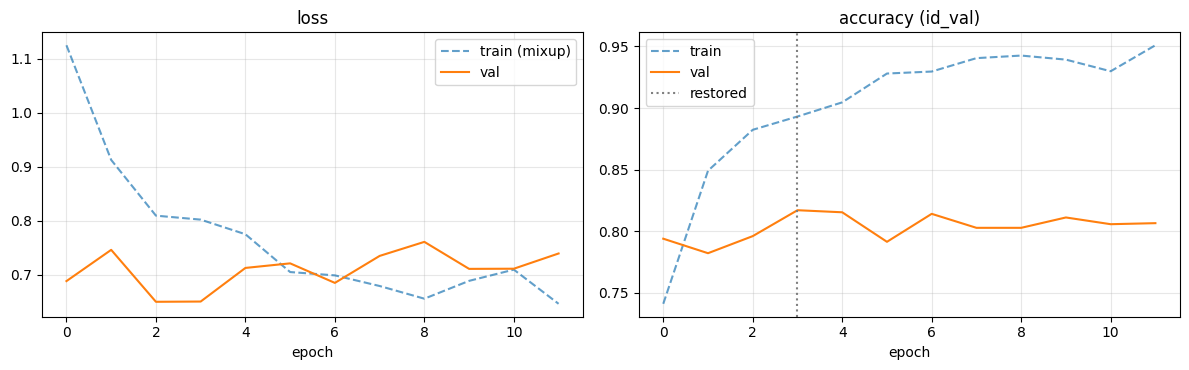

train/val gap at the final epoch: +0.144   (v2's ResNet ended at +0.215)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.8))
axes[0].plot(hist["train_loss"], ls="--", alpha=0.7, label="train (mixup)")
axes[0].plot(hist["val_loss"], label="val")
axes[1].plot(hist["train_acc"], ls="--", alpha=0.7, label="train")
axes[1].plot(hist["val_acc"], label="val")
axes[1].axvline(hist["best_epoch"] - 1, color="gray", ls=":", label="restored")

axes[0].set_title("loss")
axes[1].set_title("accuracy (id_val)")
for ax in axes:
    ax.set_xlabel("epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

gap = hist["train_acc"][-1] - hist["val_acc"][-1]
print(f"train/val gap at the final epoch: {gap:+.3f}   (v2's ResNet ended at +0.215)")

## 6. Evaluation

`honest_macro_f1` is the number to quote. Black-fronted duiker and `empty` occupy cameras
that no other class appears at, so both can be scored correctly from the background alone —
section 6.1 of the v2 notebook has the camera-overlap table. Excluding them leaves the eight
classes that actually require telling animals apart.

In [12]:
from sklearn.metrics import f1_score, confusion_matrix, classification_report

SITE_SEPARABLE = ["black-fronted duiker", "empty (false trigger)"]


def honest_macro_f1(truth, preds, exclude=SITE_SEPARABLE):
    "Macro F1 over the classes that actually require telling animals apart."
    per_class = f1_score(truth, preds, average=None,
                         labels=range(N_CLASSES), zero_division=0)
    keep = [i for i, name in enumerate(CLASS_NAMES) if name not in exclude]
    return per_class[keep].mean()


def scores(split):
    X, y = data[split]
    preds = predict(model, X).cpu().numpy()
    truth = y.cpu().numpy()
    return truth, preds


print(f"{'split':>9} {'cameras':>22} {'accuracy':>10} {'macro F1':>10} {'honest F1':>11}")
for split, description in [("id_val", "seen (held-out dates)"),
                           ("id_test", "seen (held-out dates)"),
                           ("ood_val", "never seen")]:
    truth, preds = scores(split)
    print(f"{split:>9} {description:>22} {(preds == truth).mean():>10.3f} "
          f"{f1_score(truth, preds, average='macro'):>10.3f} "
          f"{honest_macro_f1(truth, preds):>11.3f}")

    split                cameras   accuracy   macro F1   honest F1
   id_val  seen (held-out dates)      0.817      0.734       0.673
  id_test  seen (held-out dates)      0.758      0.674       0.600
  ood_val             never seen      0.637      0.543       0.446


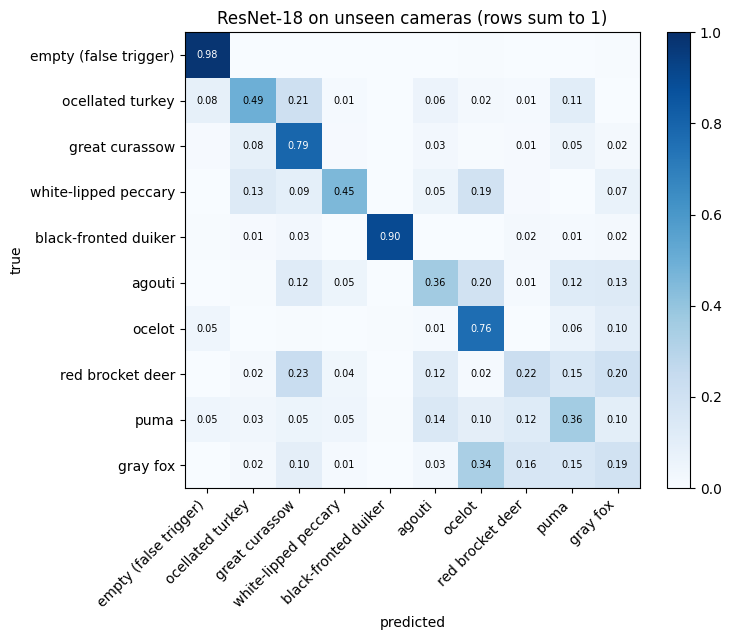

                       precision    recall  f1-score   support

empty (false trigger)      0.863     0.978     0.917       600
     ocellated turkey      0.661     0.495     0.566       600
       great curassow      0.617     0.790     0.693       600
 white-lipped peccary      0.858     0.453     0.593       600
 black-fronted duiker      0.989     0.898     0.941       600
               agouti      0.344     0.362     0.353       210
               ocelot      0.538     0.764     0.631       470
     red brocket deer      0.200     0.223     0.211       130
                 puma      0.274     0.357     0.310       241
             gray fox      0.235     0.194     0.212       310

             accuracy                          0.637      4361
            macro avg      0.558     0.551     0.543      4361
         weighted avg      0.661     0.637     0.634      4361



In [13]:
ood_truth, ood_preds = scores("ood_val")

cm = confusion_matrix(ood_truth, ood_preds, normalize="true")

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(cm, cmap="Blues", vmin=0, vmax=1)
ax.set_xticks(range(N_CLASSES), CLASS_NAMES, rotation=45, ha="right")
ax.set_yticks(range(N_CLASSES), CLASS_NAMES)
ax.set_xlabel("predicted")
ax.set_ylabel("true")
ax.set_title("ResNet-18 on unseen cameras (rows sum to 1)")

for i in range(N_CLASSES):
    for j in range(N_CLASSES):
        if cm[i, j] > 0.01:
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center", fontsize=7,
                    color="white" if cm[i, j] > 0.5 else "black")

fig.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

print(classification_report(ood_truth, ood_preds, target_names=CLASS_NAMES, digits=3,
                            zero_division=0))

## 7. Per-camera evaluation

Per-class F1 on this split is fragile, because several classes sit on very few unseen
cameras — white-lipped peccary on exactly one. A class can look solved or broken because a
single site happened to be easy or hard.

Two more robust views:

- **Per-camera accuracy**, so one large site cannot carry the average.
- **Contested cameras only**: the sites where two or more of the ten classes appear. At a
  camera where only one class was ever photographed, predicting the site is enough to be
  right, so those sites cannot distinguish a species classifier from a site classifier.

In [14]:
ood_meta = SPLITS["ood_val"].copy()
ood_meta["truth"] = ood_truth
ood_meta["pred"] = ood_preds
ood_meta["correct"] = ood_meta.truth == ood_meta.pred

classes_per_camera = ood_meta.groupby("location_remapped").truth.nunique()
CONTESTED = sorted(classes_per_camera[classes_per_camera >= 2].index)

print(f"{'camera':>7} {'images':>7} {'classes':>8} {'accuracy':>9}")
for cam, grp in ood_meta.groupby("location_remapped"):
    mark = "  <- contested" if cam in CONTESTED else ""
    print(f"{cam:>7} {len(grp):>7,} {grp.truth.nunique():>8} {grp.correct.mean():>9.3f}{mark}")

by_camera = ood_meta.groupby("location_remapped").correct.mean()
print(f"\nimage-weighted accuracy   {ood_meta.correct.mean():.3f}")
print(f"camera-weighted accuracy  {by_camera.mean():.3f}  "
      f"(over {len(by_camera)} cameras, sd {by_camera.std():.3f})")

 camera  images  classes  accuracy
      3     398        6     0.500  <- contested
     22      34        1     1.000
     27     205        5     0.507  <- contested
     40      13        1     1.000
     57     414        6     0.633  <- contested
     66     193        1     0.953
     79      62        1     1.000
     81      42        1     0.810
    114      18        1     1.000
    134      48        1     0.042
    136      12        1     0.833
    143      95        1     1.000
    153      52        1     1.000
    171       4        1     1.000
    175      91        1     0.956
    211       6        1     0.833
    217     274        1     0.854
    224      30        1     1.000
    239      62        1     1.000
    260   1,093        7     0.508  <- contested
    261       1        1     0.000
    267      44        1     1.000
    269      51        1     1.000
    273      29        1     1.000
    275       8        1     0.875
    279      50        1     1.000

In [15]:
contested = ood_meta[ood_meta.location_remapped.isin(CONTESTED)]
c_truth = contested.truth.to_numpy()
c_pred = contested.pred.to_numpy()

print(f"contested cameras: {CONTESTED}")
print(f"images at them   : {len(contested):,} of {len(ood_meta):,}")
print(f"classes present  : {contested.truth.nunique()} of {N_CLASSES}")
print()
print(f"{'metric':<34} {'all cameras':>12} {'contested only':>16}")
print(f"{'accuracy':<34} {ood_meta.correct.mean():>12.3f} {contested.correct.mean():>16.3f}")
print(f"{'macro F1':<34} {f1_score(ood_truth, ood_preds, average='macro'):>12.3f} "
      f"{f1_score(c_truth, c_pred, average='macro', zero_division=0):>16.3f}")
print(f"{'honest macro F1':<34} {honest_macro_f1(ood_truth, ood_preds):>12.3f} "
      f"{honest_macro_f1(c_truth, c_pred):>16.3f}")

contested cameras: [3, 27, 57, 260, 309, 320]
images at them   : 3,121 of 4,361
classes present  : 9 of 10

metric                              all cameras   contested only
accuracy                                  0.637            0.529
macro F1                                  0.543            0.363
honest macro F1                           0.446            0.454


## 8. The gray fox regression

In v2, gray fox was the one class the pretrained model made *worse*: F1 fell from 0.284 to
0.103 as recall collapsed to 0.061, while nearly everything else improved. A single class
falling that far while the rest rise points at a specific confusion rather than general
weakness, so it is worth resolving directly rather than treating as noise.

In [16]:
GRAY_FOX = CLASS_NAMES.index("gray fox")
fox = ood_meta[ood_meta.truth == GRAY_FOX]

print(f"gray fox: {len(fox):,} images across {fox.location_remapped.nunique()} unseen cameras")
print(f"recall now {fox.correct.mean():.3f}   (v2: 0.061)")
print()
print("predicted as:")
for cls, n in fox.pred.value_counts().items():
    print(f"  {CLASS_NAMES[cls]:<24} {n:>5,}  {n / len(fox):>6.1%}")

print("\nper camera:")
print(f"{'camera':>7} {'images':>7} {'recall':>8}  most common mistake")
for cam, grp in fox.groupby("location_remapped"):
    wrong = grp[~grp.correct].pred.value_counts()
    worst = f"{CLASS_NAMES[wrong.index[0]]} ({wrong.iloc[0]})" if len(wrong) else "-"
    print(f"{cam:>7} {len(grp):>7,} {grp.correct.mean():>8.3f}  {worst}")

# Is the model simply reluctant to predict gray fox at all, or confusing it specifically?
predicted_fox = ood_meta[ood_meta.pred == GRAY_FOX]
print(f"\ntimes gray fox was predicted: {len(predicted_fox):,} "
      f"(against {len(fox):,} actual); of those {predicted_fox.correct.mean():.1%} were right")

gray fox: 310 images across 5 unseen cameras
recall now 0.194   (v2: 0.061)

predicted as:
  ocelot                     105   33.9%
  gray fox                    60   19.4%
  red brocket deer            49   15.8%
  puma                        48   15.5%
  great curassow              30    9.7%
  agouti                       9    2.9%
  ocellated turkey             5    1.6%
  white-lipped peccary         4    1.3%

per camera:
 camera  images   recall  most common mistake
      3     110    0.200  ocelot (43)
     27      50    0.320  red brocket deer (18)
    260      20    0.200  puma (7)
    309      80    0.212  ocelot (62)
    320      50    0.020  red brocket deer (31)

times gray fox was predicted: 255 (against 310 actual); of those 23.5% were right


Read this two ways. If the mistakes concentrate in one or two other classes, it is a
confusion between similar-looking animals and more data or a detector crop should fix it. If
gray fox is simply predicted far less often than it occurs, the model has learned to
suppress the class — a calibration problem, treatable with class-balanced loss weights or a
higher decision threshold on the competing classes.

## 9. Comparison with v2

Both notebooks use identical splits, sampling and seed, so the columns are directly
comparable.

| model | input | held-out dates | unseen cameras | honest |
|---|---|---|---|---|
| SmallCNN from scratch | 64x64 | 0.545 | 0.434 | 0.320 |
| SmallCNN from scratch | 128x128 | 0.504 | 0.424 | 0.313 |
| ResNet-18, single LR, no mixup | 128x128 | 0.666 | 0.505 | 0.421 |
| **ResNet-18, this notebook** | **192x192** | **0.674** | **0.543** | **0.446** |

The honest column cleared 0.421, so resolution and regularization did buy generalization —
but note the size of the step. Pretraining moved it 0.320 to 0.421; everything in this
notebook moved it a further 0.025.

In [17]:
truth, preds = scores("id_test")
o_truth, o_preds = scores("ood_val")

print(f"{'model':<34} {'input':>9} {'dates':>8} {'cameras':>9} {'honest':>8}")
print(f"{'SmallCNN scratch (v2)':<34} {'64x64':>9} {0.545:>8.3f} {0.434:>9.3f} {0.320:>8.3f}")
print(f"{'ResNet-18 single LR (v2)':<34} {'128x128':>9} {0.666:>8.3f} {0.505:>9.3f} {0.421:>8.3f}")
print(f"{'ResNet-18 + disc. LR + mixup (v3)':<34} {f'{IMG_SIZE}x{IMG_SIZE}':>9} "
      f"{f1_score(truth, preds, average='macro'):>8.3f} "
      f"{f1_score(o_truth, o_preds, average='macro'):>9.3f} "
      f"{honest_macro_f1(o_truth, o_preds):>8.3f}")
print(f"\ntrained in {hist['seconds'] / 60:.0f} min, best epoch {hist['best_epoch']} of {EPOCHS}")

model                                  input    dates   cameras   honest
SmallCNN scratch (v2)                  64x64    0.545     0.434    0.320
ResNet-18 single LR (v2)             128x128    0.666     0.505    0.421
ResNet-18 + disc. LR + mixup (v3)    192x192    0.674     0.543    0.446

trained in 16 min, best epoch 4 of 12
